In [2]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt

In [3]:
img_raw=cv2.imread('/media/kusum-agrawal/New Volume/SEM6/DIP/assignment1/mri.png')
img=cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)


2.1 chan vese

In [4]:
def chan_vese(img, iters=200, mu=0.1, lambda1=1.0, lambda2=1.0, dt=0.5, eps=1.0):
    I=img.astype(np.float32)  #convert to float
    phi=np.ones_like(I)  #initial level set function
    phi[20:-20, 20:-20]=-1

    for i in range(iters):
        H = 0.5*(1+(2/np.pi)*np.arctan(phi/eps))  #Heaviside function
        delta_h = (1/np.pi) * (eps / (eps**2 + phi**2))  #Dirac delta function
        c_p=np.sum(I*H)/(np.sum(H)+1e-8)  #mean inside contour
        c_n=np.sum(I*(1-H))/(np.sum(1-H)+1e-8)  #mean outside contour

        phi_y, phi_x = np.gradient(phi)  #compute gradients
        mag = np.sqrt(phi_x**2 + phi_y**2 + 1e-8)  #magnitude of gradient
        nx = phi_x / mag  #normal x
        ny = phi_y / mag  #normal y

        _, dnx_dx = np.gradient(nx)  #divergence of normal
        dny_dy, _ = np.gradient(ny)
        curvature = dnx_dx + dny_dy  #curvature

        force = -lambda1*(I - c_p)**2 + lambda2*(I - c_n)**2
        phi+=dt*delta_h*(mu*curvature + force)

        if i%10==0:
            phi = np.sign(phi)

    return phi
    

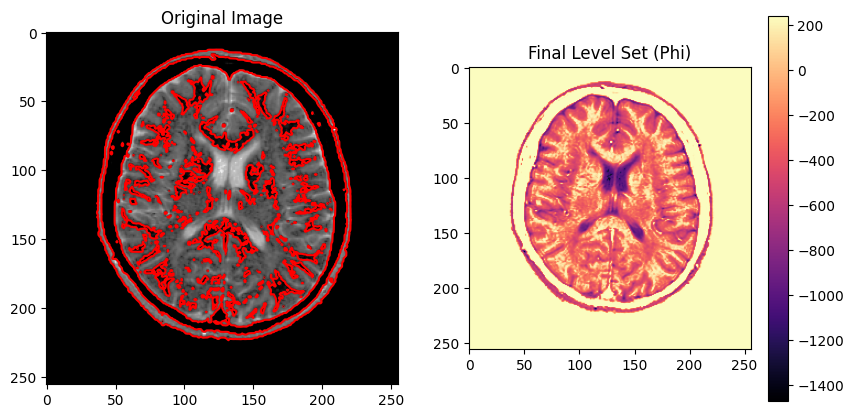

In [6]:
phi=chan_vese(img, iters=300, mu=0.2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.contour(phi, [0], colors='r') # Draw the final contour (phi=0)

plt.subplot(1, 2, 2)
plt.title("Final Level Set (Phi)")
plt.imshow(phi, cmap='magma')
plt.colorbar()
plt.show()

2.2 local binary fitting

In [ ]:
def local_active_contour(img, iters=200, mu=0.1, radius=9, dt=0.5, eps=1.0):
    I=img.astype(np.float32)
    phi=np.ones_like(I)
    phi[20:-20, 20:-20]=-1

    kernel_size=(radius*2+1, radius*2+1)

    for i in range(iters):
        H = 0.5*(1+(2/np.pi)*np.arctan(phi/eps))
        delta_h = (1/np.pi) * (eps / (eps**2 + phi**2))

        num_p=cv2.blur(I*H, kernel_size)
        den_p=cv2.blur(H, kernel_size)
        m_p=num_p/(den_p+1e-8)

        num_n=cv2.blur(I*(1-H), kernel_size)
        den_n=cv2.blur(1-H, kernel_size)
        m_n=num_n/(den_n+1e-8)
        
        phi_y, phi_x = np.gradient(phi)
        mag = np.sqrt(phi_x**2 + phi_y**2 + 1e-8)
        nx = phi_x / mag
        ny = phi_y / mag

        _, dnx_dx = np.gradient(nx)
        dny_dy, _ = np.gradient(ny)
        curvature = dnx_dx + dny_dy

        local_force = 2*(m_p-m_n)*(I-(m_p+m_n)/2)
        phi+=dt*delta_h*(mu*curvature + local_force)

        if i%10==0:
            phi = np.sign(phi)

    return phi

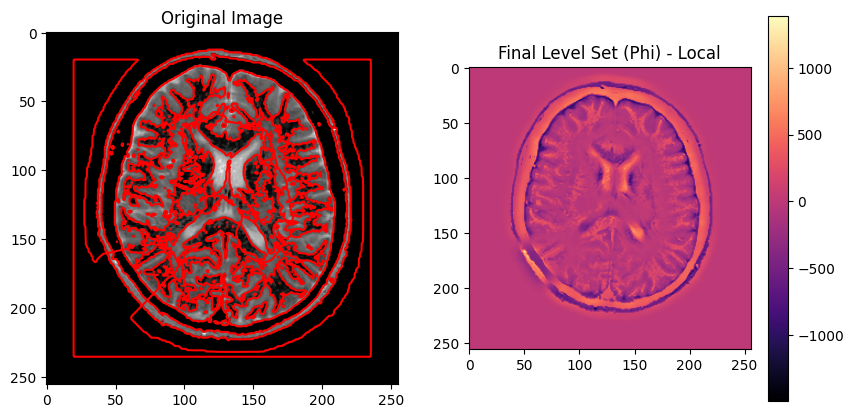

In [15]:
phi_local=local_active_contour(img, iters=300, mu=0.2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.contour(phi_local, [0], colors='r') # Draw the final contour (phi=0)
plt.subplot(1, 2, 2)
plt.title("Final Level Set (Phi) - Local")
plt.imshow(phi_local, cmap='magma')
plt.colorbar()
plt.show()

2.3 Hybrid active contour model

In [16]:
def hybrid_active_contour(img, iters=200, mu=0.1, radius=9, dt=0.5, eps=1.0):
    I=img.astype(np.float32)
    phi=np.ones_like(I)
    phi[20:-20, 20:-20]=-1

    kernel_size=(radius*2+1, radius*2+1)
    eps_stable =1e-8

    for i in range(iters):
        H = 0.5*(1+(2/np.pi)*np.arctan(phi/eps))
        delta_h = (1/np.pi) * (eps / (eps**2 + phi**2))

        num_p=cv2.GaussianBlur(I*H, kernel_size, 0, 0)
        den_p=cv2.GaussianBlur(H, kernel_size, 0, 0)
        m_p=num_p/(den_p+1e-8)

        num_n=cv2.GaussianBlur(I*(1-H), kernel_size, 0, 0)
        den_n=cv2.GaussianBlur(1-H, kernel_size, 0, 0)
        m_n=num_n/(den_n+1e-8)

        I_LFI = (m_p* cv2.GaussianBlur(H, kernel_size, 0) + m_n* cv2.GaussianBlur(1-H, kernel_size, 0, 0)) /2.0
        I_SFI = (m_p**2 * cv2.GaussianBlur(H, kernel_size, 0) + m_n**2 * cv2.GaussianBlur(1-H, kernel_size, 0, 0)) /2.0

        log_t1 = np.log(I/(I_LFI+eps_stable)+eps_stable)
        e1 = (m_p-m_n)*(1-log_t1)

        log_t2 = np.log(I**2/(I_SFI+eps_stable)+eps_stable)
        e2 = (m_p-m_n)*(1-log_t2)

        phi_y, phi_x = np.gradient(phi)
        mag = np.sqrt(phi_x**2 + phi_y**2 + 1e-8)
        nx = phi_x / mag
        ny = phi_y / mag

        _, dnx_dx = np.gradient(nx)
        dny_dy, _ = np.gradient(ny)
        curvature = dnx_dx + dny_dy

        phi+=dt*delta_h*(mu*curvature + (e1+e2))

        if i%10==0:
            phi = np.sign(phi)

    return phi

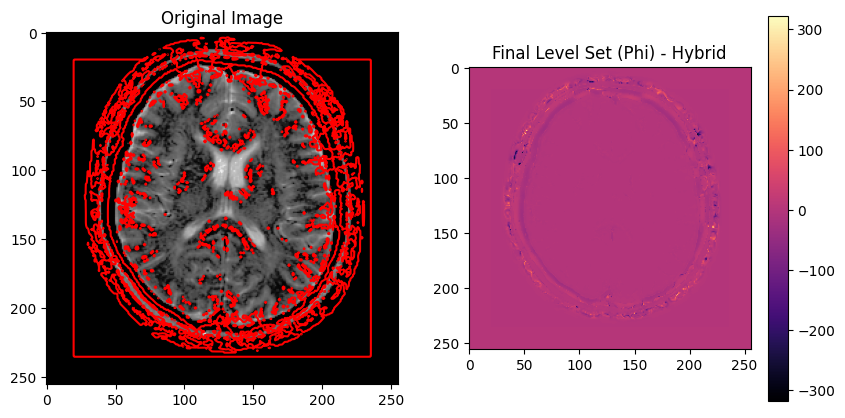

In [17]:
phi_hybrid=hybrid_active_contour(img, iters=300, mu=0.2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.contour(phi_hybrid, [0], colors='r') # Draw the final contour (phi=0)
plt.subplot(1, 2, 2)
plt.title("Final Level Set (Phi) - Hybrid")
plt.imshow(phi_hybrid, cmap='magma')
plt.colorbar()
plt.show()

3 Proposed model

In [18]:
def proposed_hybrid_active_contour(img, iters=200, mu=1.0, radius=9, tau=0.1, eps=1.0):
    I=img.astype(np.float32)
    phi=np.ones_like(I)
    phi[20:-20, 20:-20]=-1

    kernel_size=(radius*2+1, radius*2+1)

    for i in range(iters):
        H = 0.5*(1+(2/np.pi)*np.arctan(phi/eps))
        delta_h = (1/np.pi) * (eps / (eps**2 + phi**2))

        dist = np.abs(phi)
        norm_dist = (dist/ np.max(dist)+1e-8) * 2.58  #normalize to [0, 2.58] as in eq 13
        omega = (1/np.sqrt(2*np.pi))*np.exp(-0.5*norm_dist**2)

        #global c and m info
        c_p=np.sum(omega*I*H)/(np.sum(omega*H)+1e-8)
        c_n=np.sum(omega*I*(1-H))/(np.sum(omega*(1-H))+1e-8)

        m_p= cv2.blur(H*I,kernel_size)/(cv2.blur(H, kernel_size)+1e-8)
        m_n= cv2.blur((1-H)*I, kernel_size)/(cv2.blur(1-H, kernel_size)+1e-8)
        
        #energy terms
        E1 = (c_p-c_n)
        local_threshold = (m_p+m_n)/2.0

        phi_y, phi_x = np.gradient(phi)
        mag = np.sqrt(phi_x**2 + phi_y**2 + 1e-8)
        nx = phi_x / mag
        ny = phi_y / mag

        _, dnx_dx = np.gradient(nx)
        dny_dy, _ = np.gradient(ny)
        curvature = dnx_dx + dny_dy

        force = 2*omega*(c_p-c_n)*(I-local_threshold)

        phi+= tau + delta_h*(mu*curvature + force)

        if i%10==0:
            phi = np.sign(phi)
    
    return phi

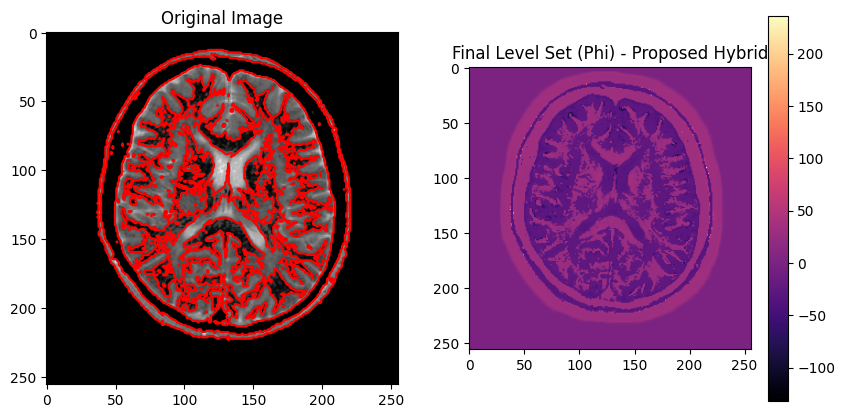

In [19]:
phi_proposed = proposed_hybrid_active_contour(img, iters=300, mu=0.2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.contour(phi_proposed, [0], colors='r') # Draw the final contour (phi=0)
plt.subplot(1, 2, 2)
plt.title("Final Level Set (Phi) - Proposed Hybrid")
plt.imshow(phi_proposed, cmap='magma')
plt.colorbar()
plt.show()